In [ ]:
# !pip install ultralytics
# !pip install pytesseract

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
from IPython.display import Image, display
import glob
from tqdm import tqdm
import yaml
import shutil
import pytesseract
from PIL import Image as PILImage
from pathlib import Path
from collections import defaultdict
from google.colab.patches import cv2_imshow
from google.cloud import storage
from tqdm import tqdm
import time
import tempfile
import json
import random


In [ ]:
dataset_path = "/content/License Plate Detection"

In [ ]:
# examing the dataset

def audit_dataset(dataset_path):
    splits = ['train', 'val', 'test']
    img_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.JPG', '.JPEG', '.PNG', '.BMP'}

    stats = {}

    for split in splits:
        img_path = f"{dataset_path}/images/{split}"
        lbl_path = f"{dataset_path}/labels/{split}"

        if os.path.exists(img_path):
            with os.scandir(img_path) as entries:
                images = sum(1 for e in entries if e.is_file() and Path(e.name).suffix in img_extensions)

            with os.scandir(lbl_path) as entries:
                labels = sum(1 for e in entries if e.is_file() and e.name.endswith('.txt'))

            stats[split] = {'images': images, 'labels': labels}
        else:
            stats[split] = {'images': 0, 'labels': 0}

    print("audit report")
    print("-"*70)
    for split, data in stats.items():
        print(f"{split.upper():6} | Images: {data['images']:6,} | Labels: {data['labels']:6,}")
    print("-"*70)

    return stats

dataset_stats = audit_dataset(dataset_path)


audit report
----------------------------------------------------------------------
TRAIN  | Images: 25,470 | Labels: 25,470
VAL    | Images:  1,073 | Labels:  1,073
TEST   | Images:    386 | Labels:    386
----------------------------------------------------------------------


In [ ]:
# checking mismatches

def count_mismatches(dataset_path, split='train'):

    img_path = f"{dataset_path}/images/{split}"
    lbl_path = f"{dataset_path}/labels/{split}"

    img_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.JPG', '.JPEG', '.PNG', '.BMP'}
    image_stems = set()

    with os.scandir(img_path) as entries:
        for entry in entries:
            if entry.is_file() and Path(entry.name).suffix in img_extensions:
                image_stems.add(Path(entry.name).stem)

    label_stems = set()

    with os.scandir(lbl_path) as entries:
        for entry in entries:
            if entry.is_file() and entry.name.endswith('.txt'):
                label_stems.add(Path(entry.name).stem)

    labels_without_images = label_stems - image_stems
    images_without_labels = image_stems - label_stems


    print("mismatch report")
    print("-"*70)
    print(f"Files to delete:")
    print(f"Labels without images: {len(labels_without_images)}")
    print(f"Images without labels: {len(images_without_labels)}")

count_mismatches(dataset_path)

mismatch report
----------------------------------------------------------------------
Files to delete:
Labels without images: 0
Images without labels: 0


In [ ]:
# deleting mismatches

def delete_mismatches(dataset_path, split='train'):

    img_path = f"{dataset_path}/images/{split}"
    lbl_path = f"{dataset_path}/labels/{split}"

    img_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.JPG', '.JPEG', '.PNG', '.BMP'}

    image_files = {}
    with os.scandir(img_path) as entries:
        for entry in entries:
            if entry.is_file() and Path(entry.name).suffix in img_extensions:
                stem = Path(entry.name).stem
                image_files[stem] = entry.name

    label_files = {}
    with os.scandir(lbl_path) as entries:
        for entry in entries:
            if entry.is_file() and entry.name.endswith('.txt'):
                stem = Path(entry.name).stem
                label_files[stem] = entry.name

    image_stems = set(image_files.keys())
    label_stems = set(label_files.keys())

    labels_without_images = label_stems - image_stems
    images_without_labels = image_stems - label_stems

    deleted = {'labels': 0, 'images': 0}

    print("Deletion Report")
    print("-"*70)

    if labels_without_images:
        print(f"\nDeleting {len(labels_without_images)} labels without images...")
        for stem in labels_without_images:
            file_path = os.path.join(lbl_path, label_files[stem])
            os.remove(file_path)
            deleted['labels'] += 1

    if images_without_labels:
        print(f"\nDeleting {len(images_without_labels)} images without labels...")
        for stem in images_without_labels:
            file_path = os.path.join(img_path, image_files[stem])
            os.remove(file_path)
            deleted['images'] += 1

    print("-"*70)
    print(f"Deleted {deleted['labels']} labels and {deleted['images']} images")

    return deleted


# delete from train dataset
delete_mismatches(dataset_path)

Deletion Report
----------------------------------------------------------------------
----------------------------------------------------------------------
Deleted 0 labels and 0 images


{'labels': 0, 'images': 0}

In [ ]:
# delete from test dataset as well

delete_mismatches(dataset_path, split='test')

Deletion Report
----------------------------------------------------------------------
----------------------------------------------------------------------
Deleted 0 labels and 0 images


{'labels': 0, 'images': 0}

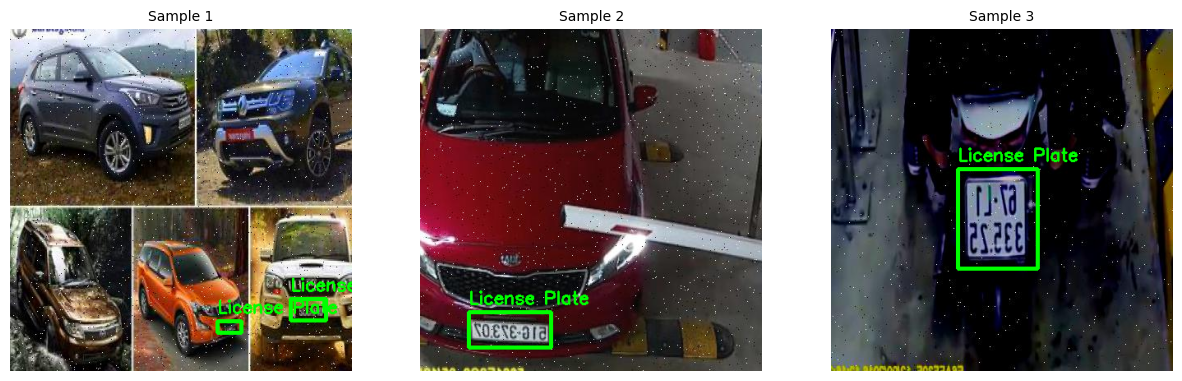

In [ ]:
# visualizing dataset

def visualize_annotations(dataset_path, split='train', num_samples=3):

    img_dir = f"{dataset_path}/images/{split}"
    lbl_dir = f"{dataset_path}/labels/{split}"

    image_files = []
    for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
        image_files.extend(glob.glob(f"{img_dir}/{ext}"))

    image_files = image_files[:num_samples]

    fig, axes = plt.subplots(1, len(image_files), figsize=(15, 5))
    if len(image_files) == 1:
        axes = [axes]

    for idx, img_path in enumerate(image_files):
        img = cv2.imread(img_path)
        if img is None:
            print(f"Could not read image: {img_path}")
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        img_name = Path(img_path).stem
        label_path = f"{lbl_dir}/{img_name}.txt"

        num_boxes = 0
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        cls, x_c, y_c, w_box, h_box = map(float, parts)

                        x_c, y_c, w_box, h_box = x_c * w, y_c * h, w_box * w, h_box * h
                        x1 = int(x_c - w_box / 2)
                        y1 = int(y_c - h_box / 2)
                        x2 = int(x_c + w_box / 2)
                        y2 = int(y_c + h_box / 2)

                        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 3)
                        cv2.putText(img, 'License Plate', (x1, y1-10),
                                  cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
                        num_boxes += 1
        else:
            print(f"No label found: {label_path}")

        axes[idx].imshow(img)
        axes[idx].set_title(f"Sample {idx+1}", fontsize=10)
        axes[idx].axis('off')

visualize_annotations(dataset_path, split='train', num_samples=3)

In [ ]:
# YOLO config file

dataset_config = {
    'path': dataset_path,
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'nc': 1,
    'names': ['license_plate']
}

yaml_path = f"{dataset_path}/dataset.yaml"

if not os.path.exists(yaml_path):
    with open(yaml_path, 'w') as f:
        yaml.dump(dataset_config, f, default_flow_style=False)


# Training Pipeline

In [ ]:
# loading the model

model = YOLO('yolov8n.pt')

print("YOLOv8 model loaded")

YOLOv8 model loaded


In [ ]:
# training configuration file

TRAINING_CONFIG = {
    'data': yaml_path,
    'epochs': 5,
    'imgsz': 640,
    'batch': 16,
    'device': 0,
    'workers': 2,
    'project': '/content/yolo_runs',
    'name': 'license_plate_detection',
    'patience': 10,
    'fraction': 1.0,
    'save': True,
    'save_period': 1,
    'cache': True,
    'optimizer': 'SGD',
    'lr0': 0.01,
    'lrf': 0.01,
    'momentum': 0.937,
    'weight_decay': 0.0005,
    'warmup_epochs': 3,
    'plots': False,
    'verbose': True,
    'amp': True,
    'cos_lr': True,
}


In [ ]:
# training the model

results = model.train(**TRAINING_CONFIG)

model.save("/content/yolo_runs/license_plate_detection/weights/trained_model.pt")

print('training complete and model saved')


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/License Plate Detection/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=license_plate_detection3, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=True

# Model Evaluation and Performance Metrics

In [ ]:
# loading the model for evaluation

model = YOLO('/content/yolo_runs/license_plate_detection3/weights/best.pt')

print("Trained model loaded for evaluation")

Trained model loaded for evaluation


In [ ]:
validation_results = model.val(
    data=yaml_path,
    split='test',
    imgsz=640,
    device=0
)

print("\n" + "-"*70)
print("validation metrics")

print(f"mAP@50: {validation_results.box.map50:.4f}")
print(f"mAP@50-95: {validation_results.box.map:.4f}")
print(f"Precision: {validation_results.box.mp:.4f}")
print(f"Recall: {validation_results.box.mr:.4f}")



Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1537.2±412.9 MB/s, size: 269.8 KB)
val: Scanning /content/License Plate Detection/labels/test.cache... 386 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 386/386 124.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 4.5it/s 5.5s
                   all        386        512      0.919      0.832      0.877      0.619
Speed: 2.3ms preprocess, 3.3ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /content/runs/detect/val3

----------------------------------------------------------------------
validation metrics
mAP@50: 0.8771
mAP@50-95: 0.6192
Precision: 0.9193
Recall: 0.8320


# Inference and Privacy Redaction

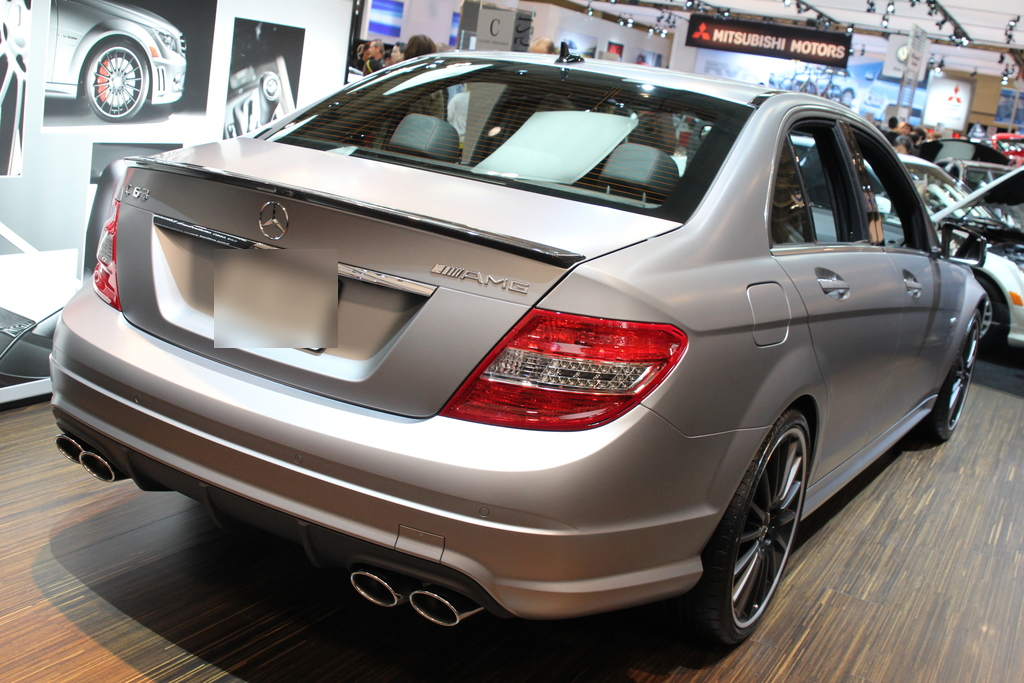

In [ ]:
# blurring license plates

def detect_and_blur_license_plates(
    image_path,
    model,
    confidence_threshold=0.5,
    blur_kernel_size=(51, 51),
    blur_sigma=0
):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not read image: {image_path}")

    anonymized_img = img.copy()

    results = model.predict(source=img, conf=confidence_threshold, device=0, verbose=False)

    detections = []

    for result in results:
        if result.boxes is None:
            continue

        for box in result.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
            confidence = float(box.conf[0].cpu().numpy())

            x1 = max(0, x1)
            y1 = max(0, y1)
            x2 = min(anonymized_img.shape[1], x2)
            y2 = min(anonymized_img.shape[0], y2)

            roi = anonymized_img[y1:y2, x1:x2]

            if roi.size > 0:
                blurred_roi = cv2.GaussianBlur(roi, blur_kernel_size, blur_sigma)
                anonymized_img[y1:y2, x1:x2] = blurred_roi

                detections.append({
                    'bbox': (x1, y1, x2, y2),
                    'confidence': confidence
                })

    return anonymized_img, detections



image_path = "/content/License Plate Detection/images/test/003a5aaf6d17c917.jpg"

anonymized_img, detections = detect_and_blur_license_plates(
    image_path=image_path,
    model=model,
    confidence_threshold=0.5
)

cv2_imshow(anonymized_img)

In [ ]:
# blurring license plates in a batch

def batch_anonymize_images(
    input_dir,
    output_dir,
    model,
    confidence_threshold=0.5,
    blur_kernel=(51, 51),
    show_progress=True
):
    os.makedirs(output_dir, exist_ok=True)

    image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.bmp']
    image_files = []
    for ext in image_extensions:
        image_files.extend(glob.glob(os.path.join(input_dir, ext)))
        image_files.extend(glob.glob(os.path.join(input_dir, ext.upper())))

    stats = {
        'total_images': len(image_files),
        'processed': 0,
        'plates_detected': 0,
        'failed': 0,
        'total_inference_time': 0,
        'low_confidence_detections': []
    }

    iterator = tqdm(image_files) if show_progress else image_files

    for img_path in iterator:
        try:
            start_time = time.time()

            anonymized_img, detections = detect_and_blur_license_plates(
                image_path=img_path,
                model=model,
                confidence_threshold=confidence_threshold,
                blur_kernel_size=blur_kernel
            )

            inference_time = time.time() - start_time
            stats['total_inference_time'] += inference_time

            output_path = os.path.join(output_dir, os.path.basename(img_path))
            cv2.imwrite(output_path, anonymized_img)

            stats['processed'] += 1
            stats['plates_detected'] += len(detections)

            for det in detections:
                if det['confidence'] < 0.7:
                    stats['low_confidence_detections'].append({
                        'image': os.path.basename(img_path),
                        'confidence': det['confidence']
                    })

        except Exception as e:
            stats['failed'] += 1
            print(f"Error processing {img_path}: {str(e)}")

    if stats['processed'] > 0:
        stats['avg_inference_latency_ms'] = (stats['total_inference_time'] / stats['processed']) * 1000

    return stats


input_dir = "/content/License Plate Detection/images/test"
output_dir = "/content/blurred_images"


stats = batch_anonymize_images(
    input_dir=input_dir,
    output_dir=output_dir,
    model=model,
    confidence_threshold=0.5
)

print(stats)


100%|██████████| 386/386 [00:10<00:00, 37.61it/s]

{'total_images': 386, 'processed': 386, 'plates_detected': 402, 'failed': 0, 'total_inference_time': 8.420864343643188, 'low_confidence_detections': [{'image': '5373ec295ea62c47.jpg', 'confidence': 0.587067186832428}, {'image': '16c15b29b30148c2.jpg', 'confidence': 0.6859574317932129}, {'image': 'c7b1e6f7c38fa1a0.jpg', 'confidence': 0.5196241736412048}, {'image': 'd5058059dc0ce0ad.jpg', 'confidence': 0.5488486886024475}, {'image': '302d636c896c263f.jpg', 'confidence': 0.5177985429763794}, {'image': '73467682c5995b65.jpg', 'confidence': 0.6185968518257141}, {'image': '4e593c88022ff6b1.jpg', 'confidence': 0.6191391944885254}, {'image': '125622a2508e3b1d.jpg', 'confidence': 0.6844609975814819}, {'image': '7a1f9520c7ecd5b1.jpg', 'confidence': 0.6670082807540894}, {'image': 'd648b2ae1abc09f3.jpg', 'confidence': 0.6582801938056946}, {'image': 'd648b2ae1abc09f3.jpg', 'confidence': 0.6547593474388123}, {'image': '65e080f9ac466664.jpg', 'confidence': 0.5788364410400391}, {'image': '27798906120e

# Blur Consistency

In [ ]:
# verifying blur consistency

def verify_blur_effectiveness(original_img_path, anonymized_img_path, detections):
    orig_img = cv2.imread(original_img_path)
    anon_img = cv2.imread(anonymized_img_path)

    results = {
        'total_plates': len(detections),
        'original_readable': 0,
        'anonymized_readable': 0,
        'blur_success_rate': 0
    }

    for det in detections:
        x1, y1, x2, y2 = det['bbox']

        orig_roi = orig_img[y1:y2, x1:x2]
        anon_roi = anon_img[y1:y2, x1:x2]

        if orig_roi.size == 0 or anon_roi.size == 0:
            continue

        orig_pil = PILImage.fromarray(cv2.cvtColor(orig_roi, cv2.COLOR_BGR2RGB))
        anon_pil = PILImage.fromarray(cv2.cvtColor(anon_roi, cv2.COLOR_BGR2RGB))

        try:
            orig_text = pytesseract.image_to_string(orig_pil, config='--psm 7')
            anon_text = pytesseract.image_to_string(anon_pil, config='--psm 7')

            if any(c.isalnum() for c in orig_text):
                results['original_readable'] += 1

            if any(c.isalnum() for c in anon_text):
                results['anonymized_readable'] += 1
        except:
            pass

    if results['total_plates'] > 0:
        successfully_blurred = results['total_plates'] - results['anonymized_readable']
        results['blur_success_rate'] = (successfully_blurred / results['total_plates']) * 100

    return results


original_image = "/content/License Plate Detection/images/test/00723dac8201a83e.jpg"
anonymized_output = "/content/blurred_images/00723dac8201a83e.jpg"

blurred_img, detections = detect_and_blur_license_plates(
    image_path=original_image,
    model=model,
    confidence_threshold=0.5
)

cv2.imwrite(anonymized_output, blurred_img)


verification_results = verify_blur_effectiveness(
    original_img_path=original_image,
    anonymized_img_path=anonymized_output,
    detections=detections
)

print(verification_results)


{'total_plates': 2, 'original_readable': 2, 'anonymized_readable': 0, 'blur_success_rate': 100.0}


# Visualisation Before and After Comparison

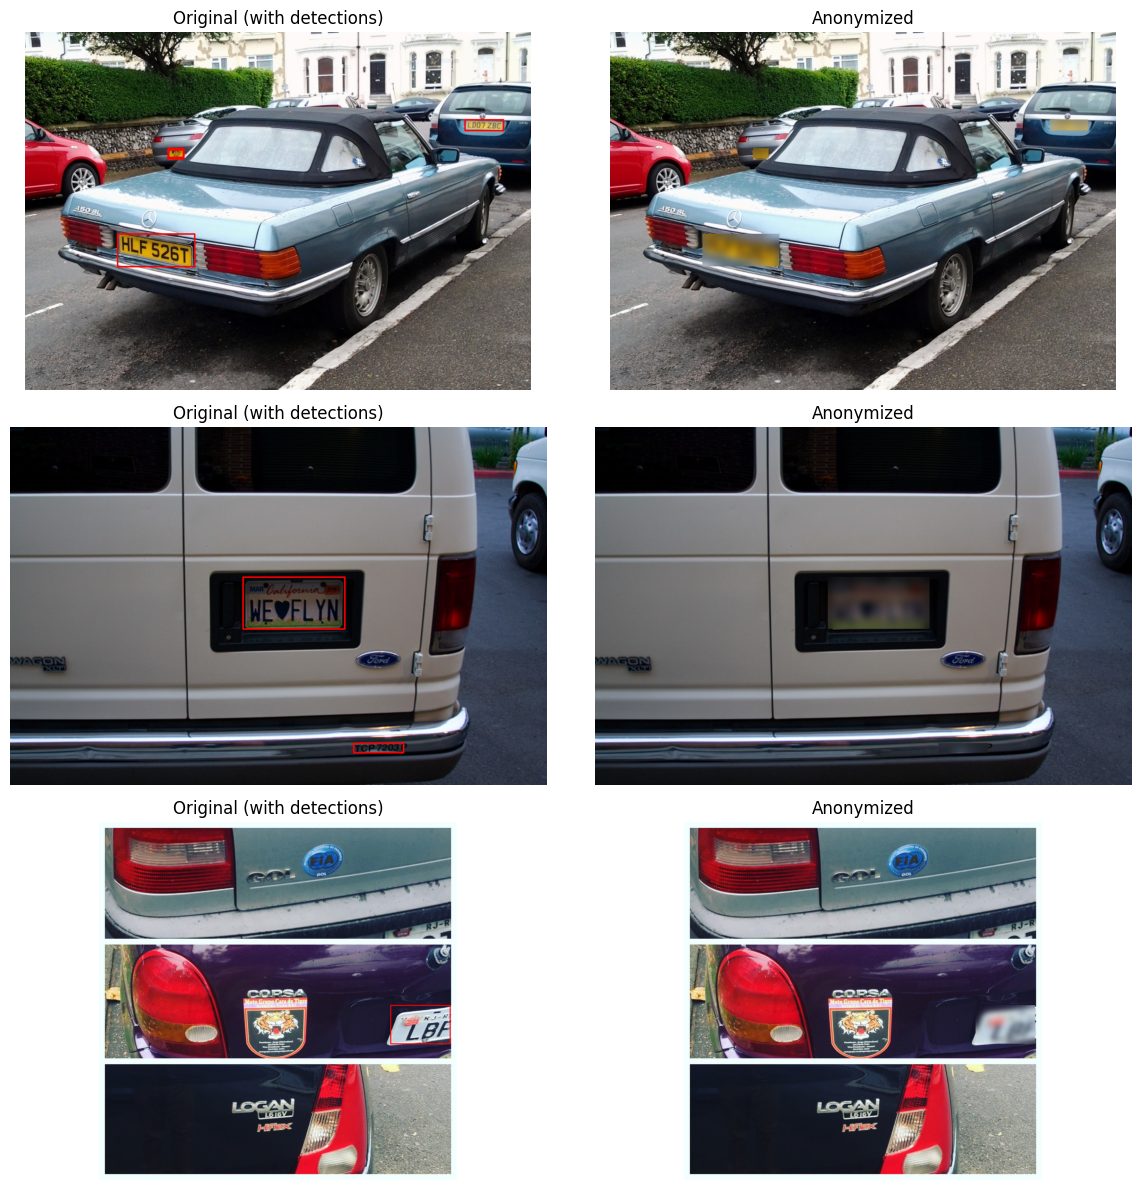

In [ ]:
# visualising the original and blurred images

def visualize_anonymization(input_dir, model, num_samples=3):

    image_paths = glob.glob(f"{input_dir}/*.jpg") + \
                  glob.glob(f"{input_dir}/*.jpeg") + \
                  glob.glob(f"{input_dir}/*.png")

    if len(image_paths) == 0:
        print("No images found in directory.")
        return

    samples = random.sample(image_paths, min(num_samples, len(image_paths)))

    fig, axes = plt.subplots(len(samples), 2, figsize=(12, 4 * len(samples)))

    if len(samples) == 1:
        axes = [axes]

    for i, img_path in enumerate(samples):
        original_img = cv2.imread(img_path)
        if original_img is None:
            continue

        original_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

        anonymized_img, detections = detect_and_blur_license_plates(
            image_path=img_path,
            model=model,
            confidence_threshold=0.3
        )
        anonymized_rgb = cv2.cvtColor(anonymized_img, cv2.COLOR_BGR2RGB)

        original_with_boxes = original_rgb.copy()
        for det in detections:
            x1, y1, x2, y2 = det['bbox']
            cv2.rectangle(original_with_boxes, (x1, y1), (x2, y2), (255, 0, 0), 2)

        axes[i][0].imshow(original_with_boxes)
        axes[i][0].set_title('Original (with detections)')
        axes[i][0].axis('off')

        axes[i][1].imshow(anonymized_rgb)
        axes[i][1].set_title('Anonymized')
        axes[i][1].axis('off')

    plt.tight_layout()
    plt.show()


visualize_anonymization(
    input_dir="/content/License Plate Detection/images/test",
    model=model,
    num_samples=3
)

# Model Export for Edge Deployment

In [ ]:
# exporting model to onnx

model = YOLO('/content/yolo_runs/license_plate_detection3/weights/best.pt')

model.export(format='onnx', imgsz=640, simplify=True)

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/yolo_runs/license_plate_detection3/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (5.9 MB)

ONNX: starting export with onnx 1.20.1 opset 22...


/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/utils.py:1447: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  warnings.warn(


ONNX: slimming with onnxslim 0.1.85...
ONNX: export success ✅ 1.3s, saved as '/content/yolo_runs/license_plate_detection3/weights/best.onnx' (11.7 MB)

Export complete (1.8s)
Results saved to /content/yolo_runs/license_plate_detection3/weights
Predict:         yolo predict task=detect model=/content/yolo_runs/license_plate_detection3/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/content/yolo_runs/license_plate_detection3/weights/best.onnx imgsz=640 data=/content/License Plate Detection/dataset.yaml  
Visualize:       https://netron.app


'/content/yolo_runs/license_plate_detection3/weights/best.onnx'

# Cloud Integration

In [ ]:
# integration with GCS

def cloud_storage_preprocessor(input_bucket, output_bucket, model,
                               confidence_threshold=0.5):

    client = storage.Client()

    input_bucket = client.bucket(input_bucket.replace("gs://", ""))
    output_bucket = client.bucket(output_bucket.replace("gs://", ""))

    blobs = input_bucket.list_blobs()

    stats = {
        'processed': 0,
        'plates_detected': 0,
        'failed': 0
    }

    for blob in blobs:
        if blob.name.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):

            try:
                with tempfile.NamedTemporaryFile(suffix=".jpg") as temp_input, \
                     tempfile.NamedTemporaryFile(suffix=".jpg") as temp_output:

                    blob.download_to_filename(temp_input.name)

                    anonymized_img, detections = detect_and_blur_license_plates(
                        image_path=temp_input.name,
                        model=model,
                        confidence_threshold=confidence_threshold
                    )

                    cv2.imwrite(temp_output.name, anonymized_img)

                    output_blob = output_bucket.blob(blob.name)
                    output_blob.upload_from_filename(temp_output.name)

                    stats['processed'] += 1
                    stats['plates_detected'] += len(detections)

            except Exception as e:
                stats['failed'] += 1
                print(f"Error processing {blob.name}: {str(e)}")

    return stats


# Continous Learning

In [ ]:
# detecting low confidence score images

def low_confidence_images(
    input_dir,
    model,
    confidence_threshold=0.3,
    review_threshold=0.7
):

    image_files = sum([glob.glob(f"{input_dir}/*.{ext}") for ext in ['jpg','jpeg','png']], [])


    low_confidence_detections = []

    for img_path in tqdm(image_files):
        try:
            results = model.predict(
                source=img_path,
                conf=confidence_threshold,
                iou=0.3,
                device=0,
                verbose=False
            )

            for result in results:
                if result.boxes is None:
                    continue

                for box in result.boxes:
                    confidence = float(box.conf[0].cpu().numpy())

                    if confidence < review_threshold:
                        low_confidence_detections.append({
                            'image': os.path.basename(img_path),
                            'confidence': confidence
                        })

        except Exception as e:
            print(f"Error processing {img_path}: {str(e)}")

    print("\n" + "-"*70)
    print("low confidence detection report")
    print(f"total images flagged: {len(low_confidence_detections)}")
    print(f"Review Threshold: {review_threshold}\n")

    for det in low_confidence_detections:
        print(f"Image: {det['image']} | Confidence: {det['confidence']:.2f}")

    print("="*70)

    return low_confidence_detections



blurred_images_dir = "/content/blurred_images"

report = low_confidence_images(
    input_dir=blurred_images_dir,
    model=model,
    confidence_threshold=0.3,
    review_threshold=0.7
)


100%|██████████| 386/386 [00:07<00:00, 53.98it/s]


----------------------------------------------------------------------
low confidence detection report
total images flagged: 332
Review Threshold: 0.7

Image: 5373ec295ea62c47.jpg | Confidence: 0.35
Image: 16c15b29b30148c2.jpg | Confidence: 0.57
Image: d5058059dc0ce0ad.jpg | Confidence: 0.38
Image: 302d636c896c263f.jpg | Confidence: 0.32
Image: 73467682c5995b65.jpg | Confidence: 0.61
Image: 39c193bcc0c00f9e.jpg | Confidence: 0.57
Image: 7a1f9520c7ecd5b1.jpg | Confidence: 0.67
Image: 7a1f9520c7ecd5b1.jpg | Confidence: 0.64
Image: d648b2ae1abc09f3.jpg | Confidence: 0.47
Image: 65e080f9ac466664.jpg | Confidence: 0.38
Image: 65e080f9ac466664.jpg | Confidence: 0.36
Image: 27798906120ea394.jpg | Confidence: 0.61
Image: 27798906120ea394.jpg | Confidence: 0.41
Image: 27798906120ea394.jpg | Confidence: 0.41
Image: 9034927e7438bdd6.jpg | Confidence: 0.47
Image: 85f0b4db3eb512ce.jpg | Confidence: 0.63
Image: 6504632e0dc25997.jpg | Confidence: 0.42
Image: 6c144e47161867c2.jpg | Confidence: 0.45
I

# Performance Benchmarking


In [ ]:
# benchmarking the performance

def benchmark_inference(model, num_iterations=100, imgsz=640):

    dummy_img = np.random.randint(0, 255, (imgsz, imgsz, 3), dtype=np.uint8)

    latencies = []

    for _ in range(10):
        _ = model.predict(source=dummy_img, device=0, verbose=False)

    print(f"running {num_iterations} inference iterations...")

    for _ in tqdm(range(num_iterations)):
        start = time.time()
        _ = model.predict(source=dummy_img, device=0, verbose=False)
        latency = (time.time() - start) * 1000
        latencies.append(latency)

    results = {
        'mean_latency_ms': np.mean(latencies),
        'median_latency_ms': np.median(latencies),
        'min_latency_ms': np.min(latencies),
        'max_latency_ms': np.max(latencies),
        'std_latency_ms': np.std(latencies),
        'fps': 1000 / np.mean(latencies),
        'throughput_images_per_hour': (3600 * 1000) / np.mean(latencies)
    }

    print("\n" + "-"*70)
    print("inference latency benchmark")
    print(f"Mean latency: {results['mean_latency_ms']:.2f} ms")
    print(f"Median latency: {results['median_latency_ms']:.2f} ms")
    print(f"Min latency: {results['min_latency_ms']:.2f} ms")
    print(f"Max latency: {results['max_latency_ms']:.2f} ms")
    print(f"Std deviation: {results['std_latency_ms']:.2f} ms")
    print(f"\nThroughput: {results['fps']:.2f} FPS")
    print(f"Scalability: {results['throughput_images_per_hour']:,.0f} images/hour")

    return results


benchmark_results = benchmark_inference(model, num_iterations=100)


running 100 inference iterations...


100%|██████████| 100/100 [00:00<00:00, 123.34it/s]


----------------------------------------------------------------------
inference latency benchmark
Mean latency: 8.05 ms
Median latency: 7.69 ms
Min latency: 7.30 ms
Max latency: 16.87 ms
Std deviation: 1.20 ms

Throughput: 124.27 FPS
Scalability: 447,378 images/hour
